In [34]:
from sklearn.datasets import make_classification    # 生成随机分类数据集
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression # 逻辑回归分类模型
from sklearn.metrics import classification_report   # 生成分类评估报告
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Kai']
plt.rcParams['axes.unicode_minus'] = False

In [35]:
"""
1. 生成数据
"""
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)

df = pd.DataFrame(X, columns=[f'feature_{i+1}' for i in range(20)])
df.insert(0, 'target', y)
df.head()

,target,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20
0,1,-0.669356,-1.495778,-0.870766,1.141831,0.021606,1.730630,-1.251698,0.289305,0.357163,...,0.829274,0.154850,-0.219970,-0.739137,1.802012,1.634606,-0.938180,-1.267337,-1.276334,1.016643
1,0,0.093372,0.785848,0.105754,1.272354,-0.846316,-0.979093,1.263707,0.264020,2.411677,...,0.543479,0.199810,0.288724,0.732492,-0.872002,-1.654887,-1.130204,-0.122709,0.693431,0.911363
2,1,-0.905797,-0.608341,0.295141,0.943716,0.092936,1.370397,-0.064772,0.287273,-0.533004,...,-0.549925,-0.510064,-0.868768,-0.598279,0.019832,0.613460,-1.779439,0.830498,-0.737332,-0.578212
3,1,-0.585793,0.389279,0.698816,0.436236,-0.315082,0.459505,1.448820,0.505558,-1.440982,...,-0.241431,1.466783,0.678728,-1.190917,-1.442381,-0.929136,-0.221600,-0.346772,0.034246,-1.040199
4,0,1.146441,0.515579,-1.222895,-0.396230,-1.293508,-0.352428,0.071254,1.239584,1.007133,...,-0.695695,-0.918127,0.604121,1.068379,-0.882271,2.303639,-0.973379,1.259233,0.360015,1.920368


In [36]:
"""
2. 划分数据集
"""
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [37]:
"""
3. 定义分类模型
"""
model = LogisticRegression()

In [38]:
"""
4. 模型训练
"""
res = model.fit(X_train, y_train)
type(res)

sklearn.linear_model._logistic.LogisticRegression

In [39]:
"""
5. 预测
"""
y_pred = model.predict(X_test)

In [40]:
"""
6. 生成分类评估报告
"""
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.82      0.88      0.85       145
           1       0.88      0.83      0.85       155

    accuracy                           0.85       300
   macro avg       0.85      0.85      0.85       300
weighted avg       0.85      0.85      0.85       300



In [41]:
"""
7.  获取预测正类的概率值
"""
y_pred_proba = model.predict_proba(X_test)[:, 1]
print(y_pred_proba[:10].round(2))

[0.61 0.87 0.51 0.78 0.95 0.05 0.23 0.79 0.74 0.31]


In [42]:
"""
8. 计算 AUC
        (Area Under the Curve) 曲线下面积
"""
from sklearn.metrics import roc_curve, roc_auc_score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(roc_auc)

0.9141713014460511


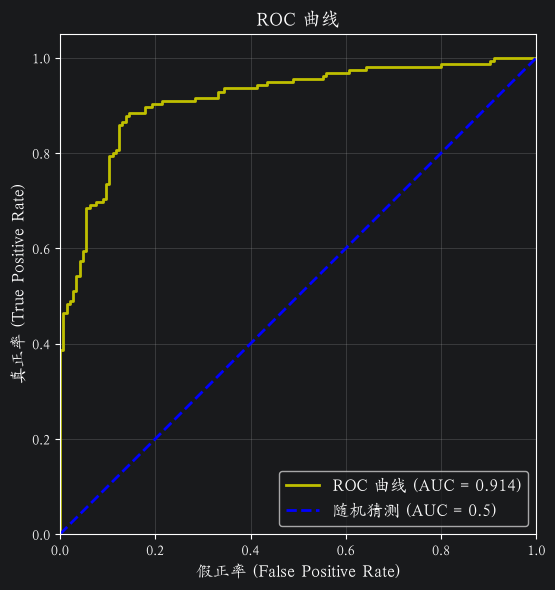

In [43]:
"""
9. 绘制 ROC 曲线
        (Receiver Operating Characteristic) 受试者工作特征
"""
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr, tpr, color='y', lw=2,
        label=f'ROC 曲线 (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='b', lw=2, linestyle='--',
        label='随机猜测 (AUC = 0.5)')

ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.05)
ax.set_xlabel('假正率 (False Positive Rate)', fontsize=12)
ax.set_ylabel('真正率 (True Positive Rate)', fontsize=12)
ax.set_title('ROC 曲线', fontsize=14)
ax.legend(loc="lower right", fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()